In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

  english_term      spanish_term  migrationsbezug_eng  migrationsbezug_spa  \
0       Abroad  En el extranjero                    0                    0   
1       Abroad  En el extranjero                    0                    0   
2       Abroad  En el extranjero                    0                    0   
3       Abroad  En el extranjero                    0                    0   
4       Abroad  En el extranjero                    0                    0   

   polysemie_eng  polysemie_spa  topic_number  \
0              1              1             5   
1              1              1             5   
2              1              1             5   
3              1              1             5   
4              1              1             5   

                                               topic  migrationsbezug_equal  \
0  Allgemeine Migration und gesellschaftlicher Ko...                      1   
1  Allgemeine Migration und gesellschaftlicher Ko...                      1   

In [3]:
clean_df = df[
    ~(
        (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
        (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
    )
].copy()

In [8]:
import pandas as pd

df = clean_df.copy()

# Sicherheit: numerisch
df['qs_migrationsbezug_eng_final'] = pd.to_numeric(df['qs_migrationsbezug_eng_final'], errors='coerce')
df['qs_migrationsbezug_spa_final'] = pd.to_numeric(df['qs_migrationsbezug_spa_final'], errors='coerce')

# Englisch
mean_eng = df[
    df['qs_migrationsbezug_eng_final'].notna()
]['qs_migrationsbezug_eng_final'].mean() * 100

# Spanisch
mean_spa = df[
    df['qs_migrationsbezug_spa_final'].notna()
]['qs_migrationsbezug_spa_final'].mean() * 100

print(f"Englisch: {mean_eng:.2f}%")
print(f"Spanisch: {mean_spa:.2f}%")

Englisch: 39.12%
Spanisch: 35.80%


In [4]:
import pandas as pd
import numpy as np
from itertools import combinations

def compute_jaccard_by_term(df, lang, migration_flag):
    """
    lang: 'eng' oder 'spa'
    migration_flag: 1 (mit) oder 0 (ohne)
    """

    qs_col = f'qs_{lang}'
    term_col = 'english_term' if lang == 'eng' else 'spanish_term'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        (df[qs_col].notna()) &
        (df[term_col].notna()) &
        (df[term_mig_col].notna()) &
        (df[term_mig_col] == migration_flag)
    ].copy()

    # Standort-ID
    subset['location_id'] = (
        subset['land'].astype(str) + " | " +
        subset['bundesstaat'].astype(str) + " | " +
        subset['stadt'].astype(str)
    )

    # Sets pro Term & Standort
    term_location_sets = (
        subset.groupby([term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    # Pairwise Jaccard
    results = []

    for term, group in term_location_sets.groupby(term_col):
        location_sets = list(zip(group['location_id'], group['qs_set']))

        if len(location_sets) < 2:
            continue

        for (_, set1), (_, set2) in combinations(location_sets, 2):
            union = set1 | set2
            if len(union) == 0:
                score = np.nan
            else:
                score = len(set1 & set2) / len(union)

            results.append(score)

    return pd.Series(results, name=f'{lang}_{migration_flag}')

In [5]:
# Englisch
eng_with = compute_jaccard_by_term(clean_df, 'eng', 1)
eng_without = compute_jaccard_by_term(clean_df, 'eng', 0)

# Spanisch
spa_with = compute_jaccard_by_term(clean_df, 'spa', 1)
spa_without = compute_jaccard_by_term(clean_df, 'spa', 0)

/tmp/ipykernel_1701/306982311.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels)


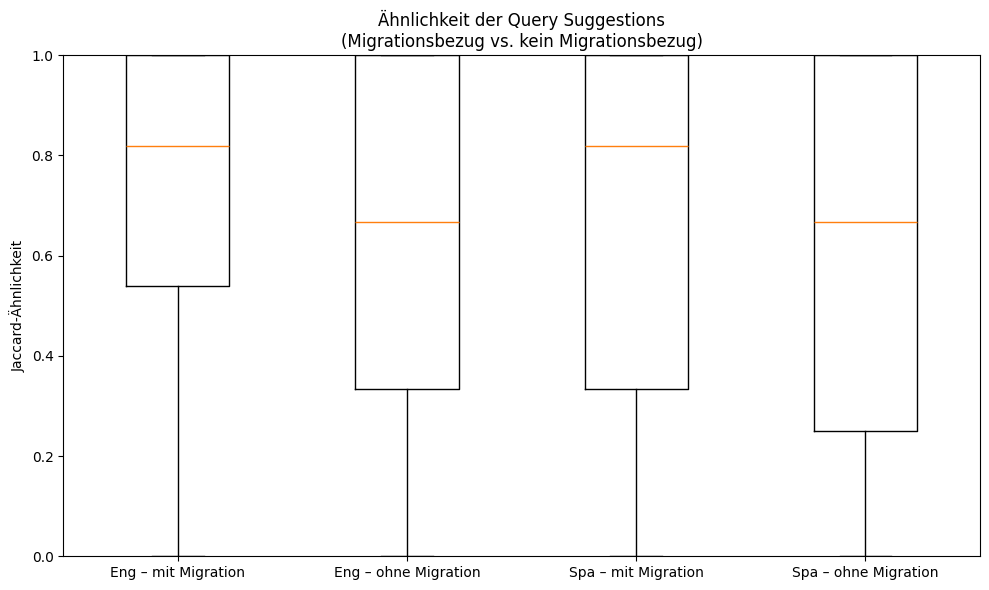

In [6]:
import matplotlib.pyplot as plt

plot_data = [
    eng_with.dropna(),
    eng_without.dropna(),
    spa_with.dropna(),
    spa_without.dropna()
]

labels = [
    'Eng – mit Migration',
    'Eng – ohne Migration',
    'Spa – mit Migration',
    'Spa – ohne Migration'
]

plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, labels=labels)

plt.ylabel('Jaccard-Ähnlichkeit')
plt.title('Ähnlichkeit der Query Suggestions\n(Migrationsbezug vs. kein Migrationsbezug)')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

                                 Englisch   Spanisch
Suchterme MIT Migrationsbezug   77.312811  74.501378
Suchterme OHNE Migrationsbezug   6.810874   5.565324


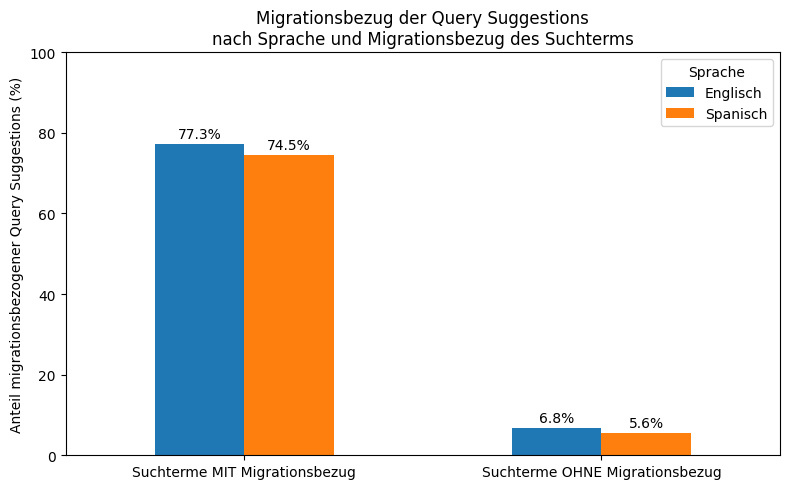

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Sicherheit: numerisch
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion zur Berechnung
# ------------------------------------------------------------
def compute_qs_migration_share(df, term_migration_flag):
    """
    term_migration_flag:
        1 = Suchterme MIT Migrationsbezug
        0 = Suchterme OHNE Migrationsbezug
    """

    # Englisch
    eng = df[
        (df['qs_eng'].notna()) &
        (df['qs_migrationsbezug_eng_final'].notna()) &
        (df['migrationsbezug_eng'] == term_migration_flag)
    ]['qs_migrationsbezug_eng_final'].mean() * 100

    # Spanisch
    spa = df[
        (df['qs_spa'].notna()) &
        (df['qs_migrationsbezug_spa_final'].notna()) &
        (df['migrationsbezug_spa'] == term_migration_flag)
    ]['qs_migrationsbezug_spa_final'].mean() * 100

    return eng, spa

# ------------------------------------------------------------
# Werte berechnen
# ------------------------------------------------------------
eng_with, spa_with = compute_qs_migration_share(df, 1)
eng_without, spa_without = compute_qs_migration_share(df, 0)

# ------------------------------------------------------------
# DataFrame für Plot
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    'Englisch': [eng_with, eng_without],
    'Spanisch': [spa_with, spa_without]
}, index=[
    'Suchterme MIT Migrationsbezug',
    'Suchterme OHNE Migrationsbezug'
])

print(plot_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ax = plot_df.plot(kind='bar', figsize=(8, 5))

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('')
plt.ylim(0, 100)
plt.title('Migrationsbezug der Query Suggestions\nnach Sprache und Migrationsbezug des Suchterms')

plt.xticks(rotation=0)
plt.legend(title='Sprache')

# Werte anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

In [ ]:
# 2. Duplikate entfernen (nur Kombination aus eng + spa zählt)
diff_unique = diff.drop_duplicates(subset=['english_term', 'spanish_term'])

# 3. Nur relevante Spalten auswählen
result = diff_unique[
    ['english_term', 'polysemie_eng','migrationsbezug_eng', 'spanish_term','polysemie_spa', 'migrationsbezug_spa']
]

# 4. Ausgeben
result

,english_term,polysemie_eng,migrationsbezug_eng,spanish_term,polysemie_spa,migrationsbezug_spa
73506,Labor certification,0,1,Certificación de Condición Laboral,1,0
211728,Alien,1,0,Extranjero,0,1
213328,Au Pair Program,0,1,Programa de Cuidado de Niños,1,0
215353,Cuban,1,0,Entrante cubano/haitiano,0,1
215673,Curricular practical training,0,1,Capacitación Práctica Curricular,1,0
224606,Parolee,1,0,Persona con Permiso de Permanencia Temporal,0,1


In [ ]:
eng_terme_themen = clean_df.groupby(['topic_number','topic'])['english_term'].nunique()

print(eng_terme_themen)

spa_terme_themen = clean_df.groupby(['topic_number','topic'])['spanish_term'].nunique()

print(spa_terme_themen)

topic_number  topic                                              
1             Rechtlicher Status und Aufenthalt                       77
2             Verfahren, Anträge, behördliche Prozesse                64
3             Dokument, Visa, formelle Nachweise                      34
4             Institutionen, Akteure, rechtliche Strukturen           48
5             Allgemeine Migration und gesellschaftlicher Kontext    112
Name: english_term, dtype: int64
topic_number  topic                                              
1             Rechtlicher Status und Aufenthalt                       77
2             Verfahren, Anträge, behördliche Prozesse                64
3             Dokument, Visa, formelle Nachweise                      34
4             Institutionen, Akteure, rechtliche Strukturen           48
5             Allgemeine Migration und gesellschaftlicher Kontext    111
Name: spanish_term, dtype: int64


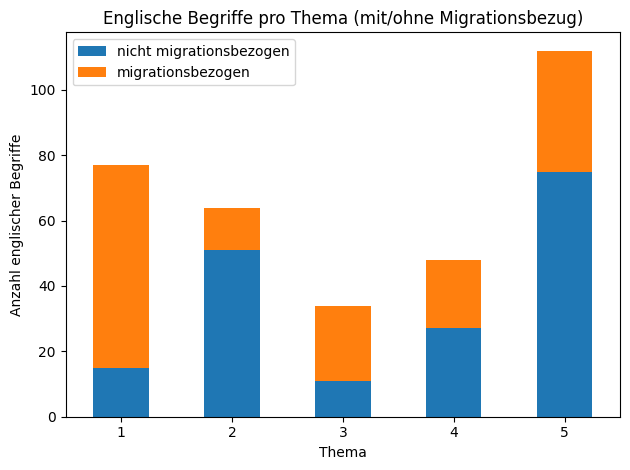

In [ ]:
grouped_eng = clean_df.groupby(['topic_number', 'migrationsbezug_eng'])['english_term'].nunique().unstack(fill_value=0)
import matplotlib.pyplot as plt

grouped_eng.plot(kind='bar', stacked=True)

plt.xlabel('Thema')
plt.ylabel('Anzahl englischer Begriffe')
plt.title('Englische Begriffe pro Thema (mit/ohne Migrationsbezug)')
plt.legend(labels=['nicht migrationsbezogen', 'migrationsbezogen'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

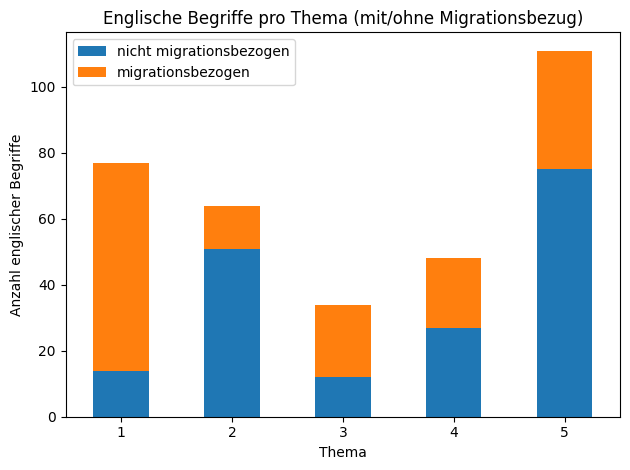

In [ ]:
grouped_spa = clean_df.groupby(['topic_number', 'migrationsbezug_spa'])['spanish_term'].nunique().unstack(fill_value=0)
import matplotlib.pyplot as plt

grouped_spa.plot(kind='bar', stacked=True)

plt.xlabel('Thema')
plt.ylabel('Anzahl englischer Begriffe')
plt.title('Englische Begriffe pro Thema (mit/ohne Migrationsbezug)')
plt.legend(labels=['nicht migrationsbezogen', 'migrationsbezogen'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
eng_terme_themen_mg = clean_df.groupby(['topic','migrationsbezug_eng'])['english_term'].nunique()

print(eng_terme_themen_mg)

spa_terme_themen_mg = clean_df.groupby(['topic','migrationsbezug_spa'])['spanish_term'].nunique()

print(spa_terme_themen_mg)

topic                                                migrationsbezug_eng
Allgemeine Migration und gesellschaftlicher Kontext  0                      75
                                                     1                      37
Dokument, Visa, formelle Nachweise                   0                      11
                                                     1                      23
Institutionen, Akteure, rechtliche Strukturen        0                      27
                                                     1                      21
Rechtlicher Status und Aufenthalt                    0                      15
                                                     1                      62
Verfahren, Anträge, behördliche Prozesse             0                      51
                                                     1                      13
Name: english_term, dtype: int64
topic                                                migrationsbezug_spa
Allgemeine Migration und gesell

In [ ]:
counts = clean_df.groupby(['topic', 'migrationsbezug_eng'])['english_term'].nunique().unstack(fill_value=0)

In [ ]:
percent = counts.div(counts.sum(axis=1), axis=0) * 100

In [ ]:
print(percent)

migrationsbezug_eng                                         0          1
topic                                                                   
Allgemeine Migration und gesellschaftlicher Kon...  66.964286  33.035714
Dokument, Visa, formelle Nachweise                  32.352941  67.647059
Institutionen, Akteure, rechtliche Strukturen       56.250000  43.750000
Rechtlicher Status und Aufenthalt                   19.480519  80.519481
Verfahren, Anträge, behördliche Prozesse            79.687500  20.312500


               Englisch   Spanisch
topic_number                      
1             61.048957  53.909220
2             26.869078  21.451170
3             65.114773  60.930654
4             42.231398  36.298372
5             22.987675  25.229464


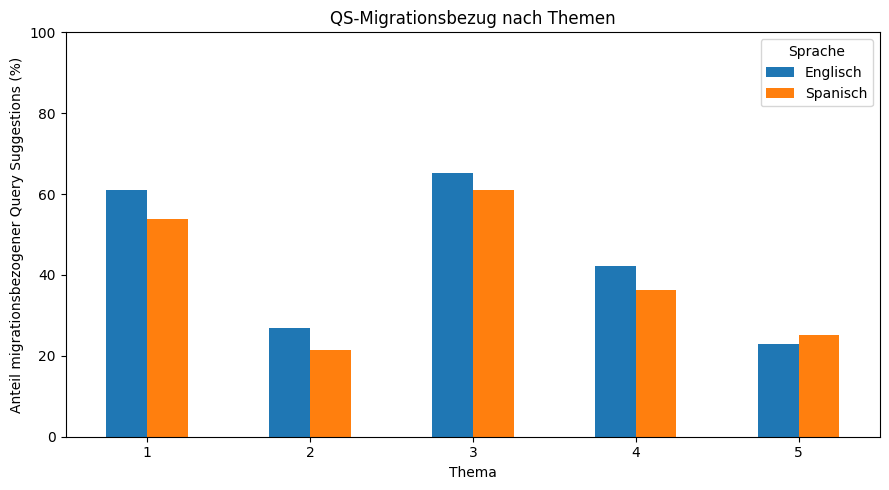

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# ------------------------------------------------------------
# ENGLISCH:
# Anteil migrationsbezogener englischer QS pro Thema
# ------------------------------------------------------------
subset_eng = df[
    (df['qs_eng'].notna()) &
    (df['qs_migrationsbezug_eng_final'].notna()) &
    (df['topic_number'].notna())
].copy()

eng_by_topic = (
    subset_eng
    .groupby('topic_number')['qs_migrationsbezug_eng_final']
    .mean()
    * 100
)

# ------------------------------------------------------------
# SPANISCH:
# Anteil migrationsbezogener spanischer QS pro Thema
# ------------------------------------------------------------
subset_spa = df[
    (df['qs_spa'].notna()) &
    (df['qs_migrationsbezug_spa_final'].notna()) &
    (df['topic_number'].notna())
].copy()

spa_by_topic = (
    subset_spa
    .groupby('topic_number')['qs_migrationsbezug_spa_final']
    .mean()
    * 100
)

# ------------------------------------------------------------
# Beide in eine Tabelle bringen
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    'Englisch': eng_by_topic,
    'Spanisch': spa_by_topic
}).fillna(0)

print(plot_df)

# ------------------------------------------------------------
# Plot
# -> ergibt 10 Balken: pro Thema je 1 Balken für Englisch und Spanisch
# ------------------------------------------------------------
ax = plot_df.plot(kind='bar', figsize=(9, 5))

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen')

plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()

Suchterme MIT Migrationsbezug:
               Englisch   Spanisch
topic_number                      
1             74.457728  66.702323
2             85.551995  80.591095
3             92.649327  86.854488
4             90.362688  82.731760
5             62.780169  71.727749

Suchterme OHNE Migrationsbezug:
               Englisch   Spanisch
topic_number                      
1             10.439024   9.998117
2             12.274516   8.308217
3              7.550317  14.407853
4              5.786452   4.262225
5              2.652503   2.061054


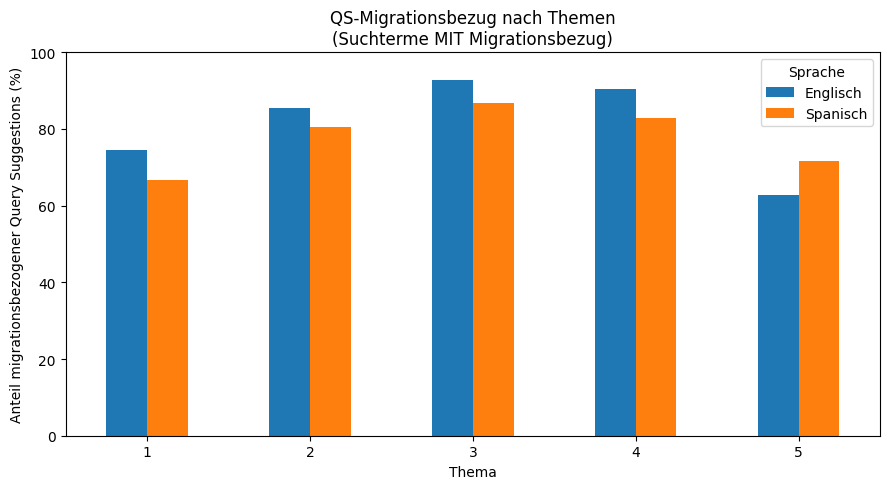

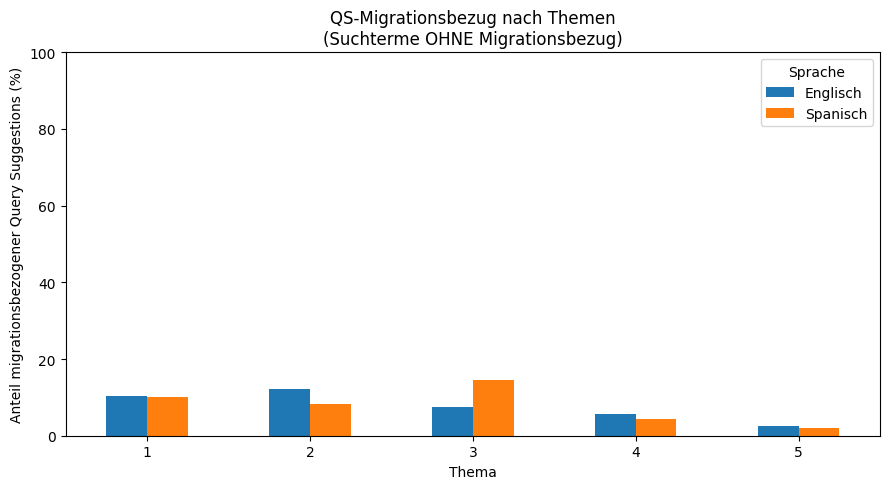

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Optional: falls die Spalten nicht sauber numerisch/boolesch sind
# hier sicherstellen, dass 0/1 bzw. True/False sauber verarbeitet werden
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion:
# Anteil migrationsbezogener QS pro Thema
# getrennt nach Suchtermen mit / ohne Migrationsbezug
# ------------------------------------------------------------
def qs_share_by_topic(df, lang):
    """
    lang = 'eng' oder 'spa'

    Gibt zwei Series zurück:
    - Anteil migrationsbezogener QS pro Thema für Suchterme MIT Migrationsbezug
    - Anteil migrationsbezogener QS pro Thema für Suchterme OHNE Migrationsbezug
    """

    qs_col = f'qs_{lang}'
    qs_mig_col = f'qs_migrationsbezug_{lang}_final'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        df[qs_col].notna() &
        df[qs_mig_col].notna() &
        df[term_mig_col].notna() &
        df['topic_number'].notna()
    ].copy()

    # Suchterme MIT Migrationsbezug
    with_mig = (
        subset[subset[term_mig_col] == 1]
        .groupby('topic_number')[qs_mig_col]
        .mean() * 100
    )

    # Suchterme OHNE Migrationsbezug
    without_mig = (
        subset[subset[term_mig_col] == 0]
        .groupby('topic_number')[qs_mig_col]
        .mean() * 100
    )

    return with_mig, without_mig

# ------------------------------------------------------------
# Englisch und Spanisch getrennt berechnen
# ------------------------------------------------------------
eng_with_mig, eng_without_mig = qs_share_by_topic(df, 'eng')
spa_with_mig, spa_without_mig = qs_share_by_topic(df, 'spa')

# ------------------------------------------------------------
# In zwei Plot-Tabellen zusammenführen
# ------------------------------------------------------------
plot_df_with_mig = pd.DataFrame({
    'Englisch': eng_with_mig,
    'Spanisch': spa_with_mig
}).fillna(0).sort_index()

plot_df_without_mig = pd.DataFrame({
    'Englisch': eng_without_mig,
    'Spanisch': spa_without_mig
}).fillna(0).sort_index()

print("Suchterme MIT Migrationsbezug:")
print(plot_df_with_mig)

print("\nSuchterme OHNE Migrationsbezug:")
print(plot_df_without_mig)

# ------------------------------------------------------------
# Plot 1: Suchterme MIT Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_with_mig.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen\n(Suchterme MIT Migrationsbezug)')
plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Suchterme OHNE Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_without_mig.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen\n(Suchterme OHNE Migrationsbezug)')
plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()


=== Mexiko ===
               Englisch   Spanisch
topic_number                      
1             60.616076  52.096899
2             26.933756  19.070073
3             66.444691  57.506780
4             40.850949  33.394893
5             23.594452  24.289345


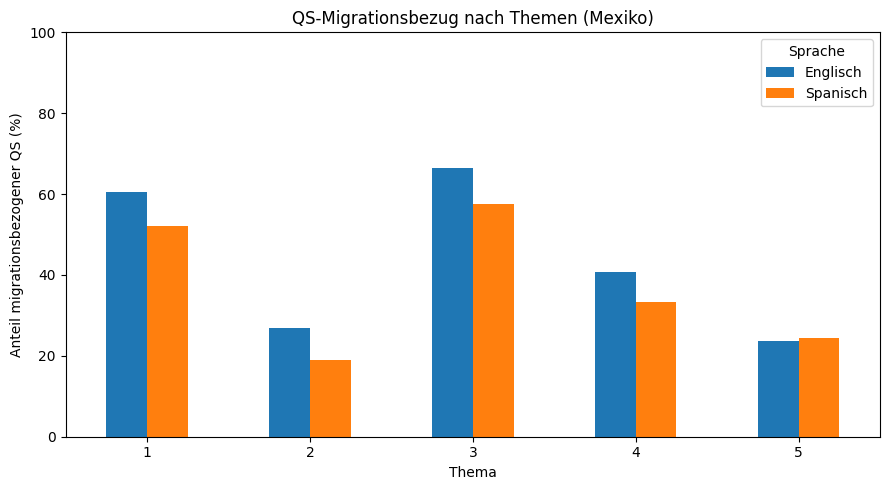


=== USA ===
               Englisch   Spanisch
topic_number                      
1             61.321566  55.043337
2             26.827722  22.971943
3             64.268049  63.119118
4             43.107352  38.171458
5             22.598010  25.831096


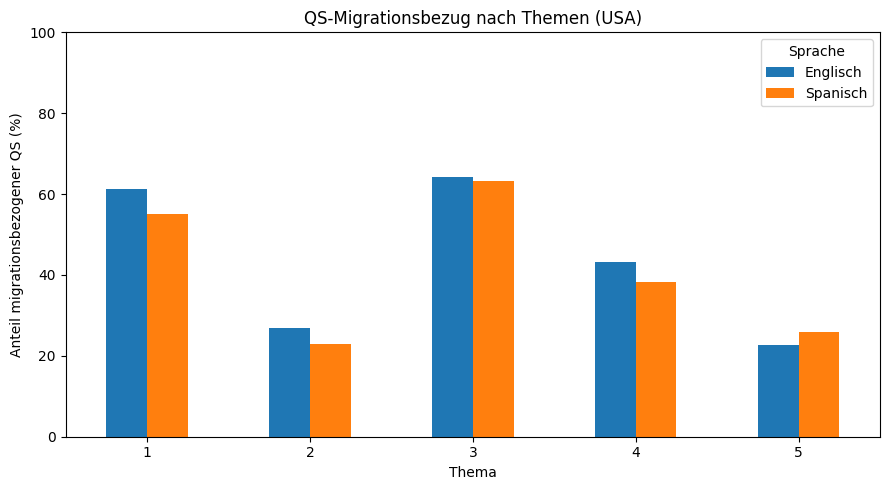

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = clean_df.copy()

# Nur relevante Länder (optional, falls mehr drin sind)
laender = ['Mexiko', 'USA']

for land in laender:

    df_land = df[df['land'] == land]

    # ------------------------------------------------------------
    # ENGLISCH
    # ------------------------------------------------------------
    subset_eng = df_land[
        (df_land['qs_eng'].notna()) &
        (df_land['qs_migrationsbezug_eng_final'].notna()) &
        (df_land['topic_number'].notna())
    ]

    eng_by_topic = (
        subset_eng
        .groupby('topic_number')['qs_migrationsbezug_eng_final']
        .mean()
        * 100
    )

    # ------------------------------------------------------------
    # SPANISCH
    # ------------------------------------------------------------
    subset_spa = df_land[
        (df_land['qs_spa'].notna()) &
        (df_land['qs_migrationsbezug_spa_final'].notna()) &
        (df_land['topic_number'].notna())
    ]

    spa_by_topic = (
        subset_spa
        .groupby('topic_number')['qs_migrationsbezug_spa_final']
        .mean()
        * 100
    )

    # ------------------------------------------------------------
    # Zusammenführen
    # ------------------------------------------------------------
    plot_df = pd.DataFrame({
        'Englisch': eng_by_topic,
        'Spanisch': spa_by_topic
    }).fillna(0)

    print(f"\n=== {land} ===")
    print(plot_df)

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    ax = plot_df.plot(kind='bar', figsize=(9, 5))

    plt.ylabel('Anteil migrationsbezogener QS (%)')
    plt.xlabel('Thema')
    plt.ylim(0, 100)
    plt.title(f'QS-Migrationsbezug nach Themen ({land})')

    plt.xticks(rotation=0)
    plt.legend(title='Sprache')


    plt.tight_layout()
    plt.show()

=== Suchterme MIT Migrationsbezug ===
              Englisch – USA  Spanisch – USA  Englisch – Mexiko  \
topic_number                                                      
1                  74.934287       68.078190          73.697742   
2                  85.145215       81.928467          86.193097   
3                  91.935905       88.467111          93.768789   
4                  92.084904       85.688844          87.652201   
5                  62.393252       73.711487          63.381658   

              Spanisch – Mexiko  
topic_number                     
1                     64.495393  
2                     78.484349  
3                     84.343510  
4                     78.178257  
5                     68.640312  

=== Suchterme OHNE Migrationsbezug ===
              Englisch – USA  Spanisch – USA  Englisch – Mexiko  \
topic_number                                                      
1                   9.533333       10.013844          11.854167   
2            

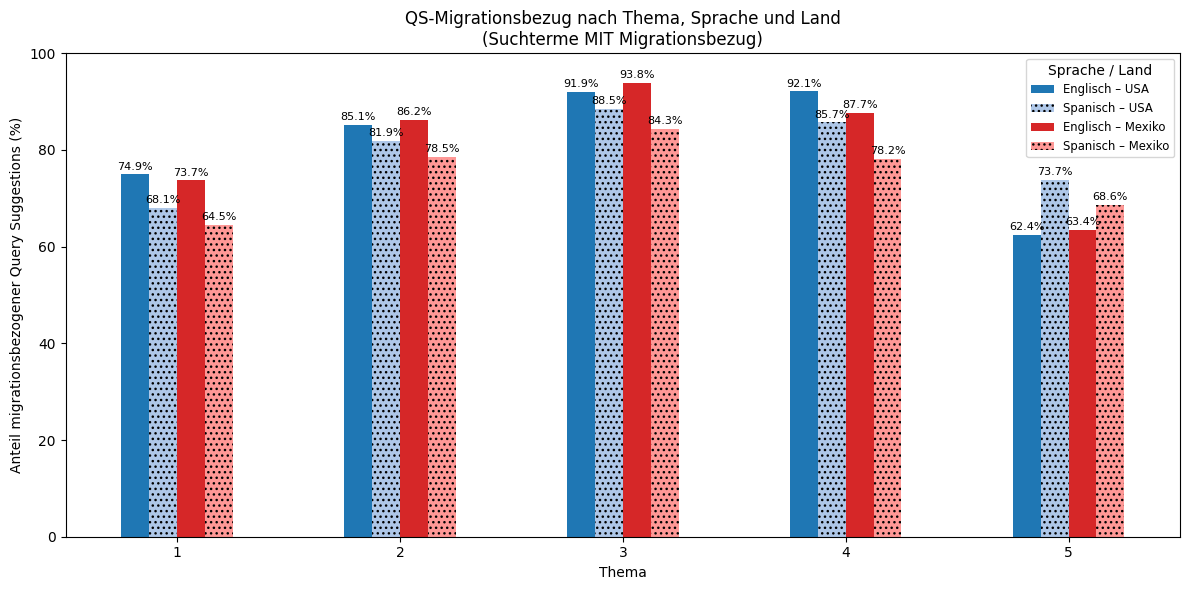

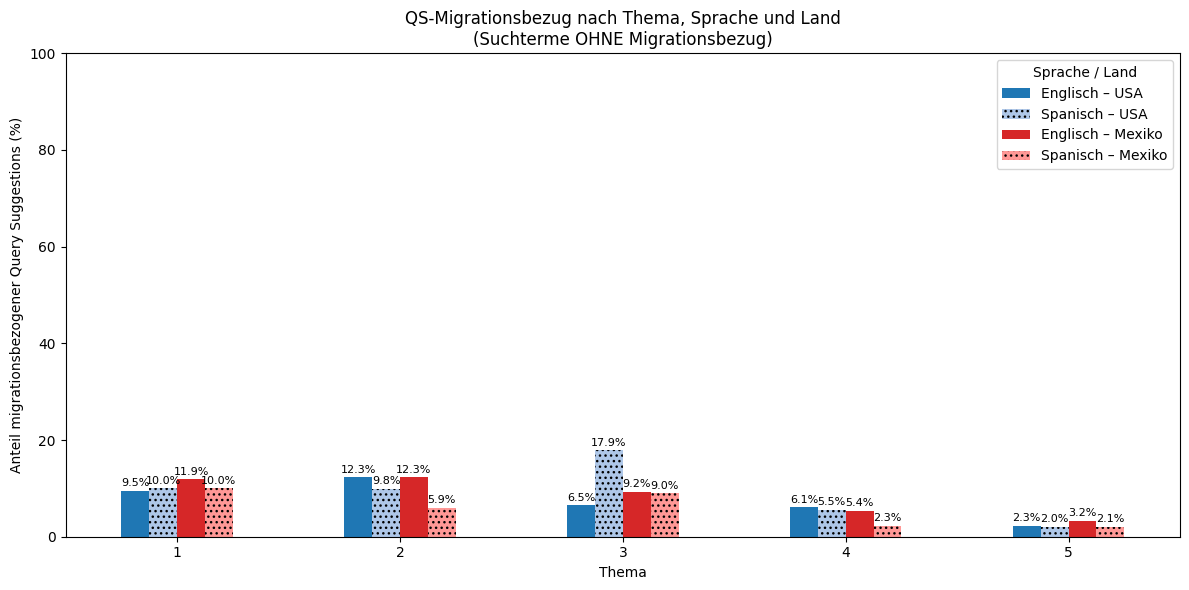

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Relevante Länder
laender = ['USA', 'Mexiko']

# Sicherheit: relevante Spalten numerisch machen
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa',
    'topic_number'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion zum Berechnen der Werte
# ------------------------------------------------------------
def build_plot_df(df, term_has_migration):
    """
    term_has_migration:
        1 = nur Suchterme MIT Migrationsbezug
        0 = nur Suchterme OHNE Migrationsbezug
    """

    result = {}

    for land in laender:
        df_land = df[df['land'] == land]

        # Englisch
        subset_eng = df_land[
            (df_land['qs_eng'].notna()) &
            (df_land['qs_migrationsbezug_eng_final'].notna()) &
            (df_land['migrationsbezug_eng'].notna()) &
            (df_land['migrationsbezug_eng'] == term_has_migration) &
            (df_land['topic_number'].notna())
        ]

        eng_by_topic = (
            subset_eng
            .groupby('topic_number')['qs_migrationsbezug_eng_final']
            .mean() * 100
        )

        # Spanisch
        subset_spa = df_land[
            (df_land['qs_spa'].notna()) &
            (df_land['qs_migrationsbezug_spa_final'].notna()) &
            (df_land['migrationsbezug_spa'].notna()) &
            (df_land['migrationsbezug_spa'] == term_has_migration) &
            (df_land['topic_number'].notna())
        ]

        spa_by_topic = (
            subset_spa
            .groupby('topic_number')['qs_migrationsbezug_spa_final']
            .mean() * 100
        )

        result[f'Englisch – {land}'] = eng_by_topic
        result[f'Spanisch – {land}'] = spa_by_topic

    plot_df = pd.DataFrame(result).fillna(0).sort_index()
    return plot_df

# ------------------------------------------------------------
# Daten für beide Gruppen
# ------------------------------------------------------------
plot_df_with_mig = build_plot_df(df, term_has_migration=1)
plot_df_without_mig = build_plot_df(df, term_has_migration=0)

print("=== Suchterme MIT Migrationsbezug ===")
print(plot_df_with_mig)

print("\n=== Suchterme OHNE Migrationsbezug ===")
print(plot_df_without_mig)

# ------------------------------------------------------------
# Farben und Hatches
# ------------------------------------------------------------
colors = [
    '#1f77b4',  # Englisch – USA
    '#aec7e8',  # Spanisch – USA
    '#d62728',  # Englisch – Mexiko
    '#ff9896'   # Spanisch – Mexiko
]

hatches = ['', '...', '', '...']  # Spanisch gepunktet

# ------------------------------------------------------------
# Plot 1: Suchterme MIT Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_with_mig.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme MIT Migrationsbezug)')
plt.xticks(rotation=0)

ax.legend(title='Sprache / Land',fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Suchterme OHNE Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_without_mig.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme OHNE Migrationsbezug)')
plt.xticks(rotation=0)
ax.legend(title='Sprache / Land')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Sicherheit: numerisch machen
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
def build_plot_df(df, term_has_migration):
    """
    term_has_migration = 1 (mit Bezug) oder 0 (ohne Bezug)
    """

    # Englisch (USA)
    eng = df[
        (df['qs_eng'].notna()) &
        (df['qs_migrationsbezug_eng_final'].notna()) &
        (df['migrationsbezug_eng'] == term_has_migration) &
        (df['topic_number'].notna())
    ].groupby('topic_number')['qs_migrationsbezug_eng_final'].mean() * 100

    # Spanisch (USA)
    spa = df[
        (df['qs_spa'].notna()) &
        (df['qs_migrationsbezug_spa_final'].notna()) &
        (df['migrationsbezug_spa'] == term_has_migration) &
        (df['topic_number'].notna())
    ].groupby('topic_number')['qs_migrationsbezug_spa_final'].mean() * 100

    plot_df = pd.DataFrame({
        'Englisch – USA': eng,
        'Spanisch – USA': spa,
        'Englisch – Mexiko': eng,   # falls gleiche Basis wie vorher
        'Spanisch – Mexiko': spa
    }).fillna(0).sort_index()

    return plot_df

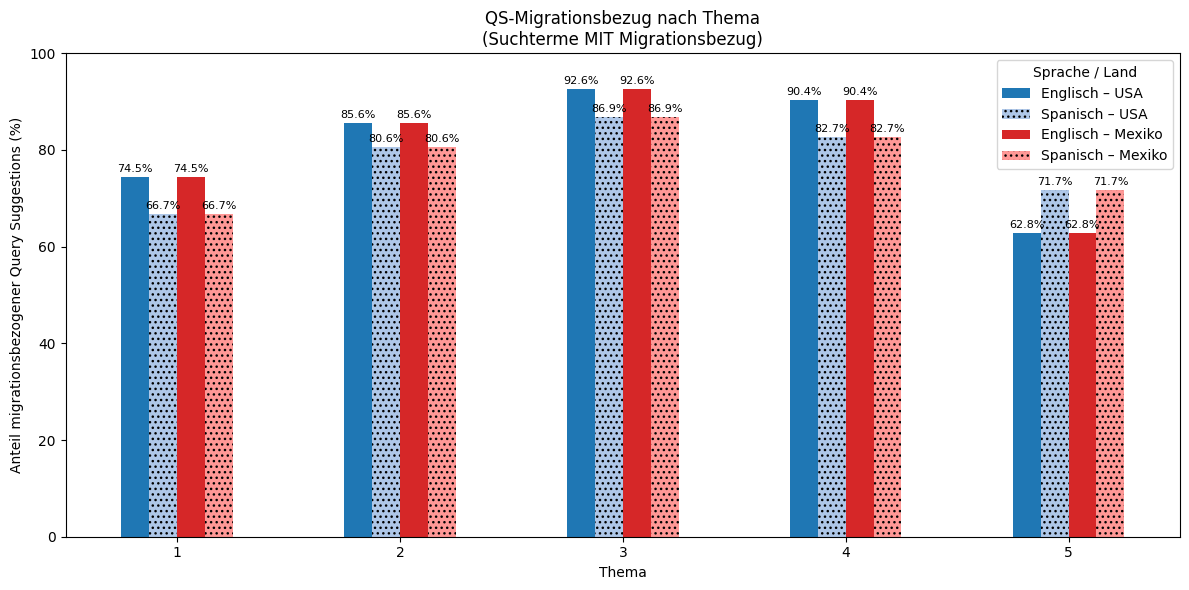

In [ ]:
plot_df_with = build_plot_df(df, term_has_migration=1)

colors = ['#1f77b4', '#aec7e8', '#d62728', '#ff9896']
hatches = ['', '...', '', '...']

ax = plot_df_with.plot(kind='bar', figsize=(12, 6), color=colors)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema\n(Suchterme MIT Migrationsbezug)')

plt.xticks(rotation=0)

ax.legend(title='Sprache / Land')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

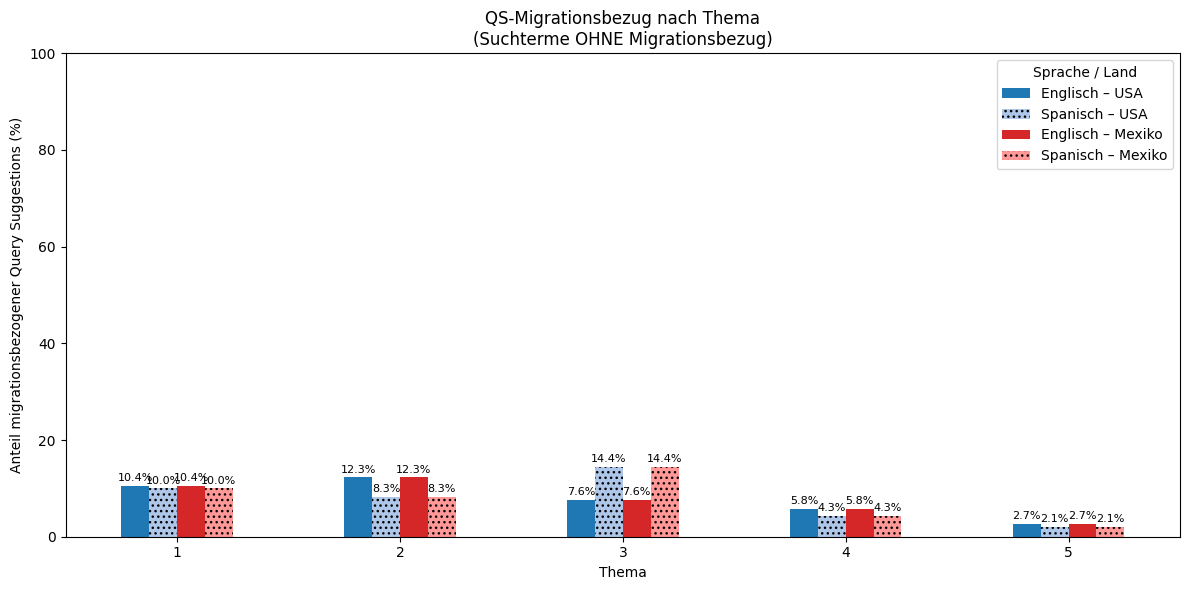

In [ ]:
plot_df_without = build_plot_df(df, term_has_migration=0)

ax = plot_df_without.plot(kind='bar', figsize=(12, 6), color=colors)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema\n(Suchterme OHNE Migrationsbezug)')

plt.xticks(rotation=0)

ax.legend(title='Sprache / Land')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

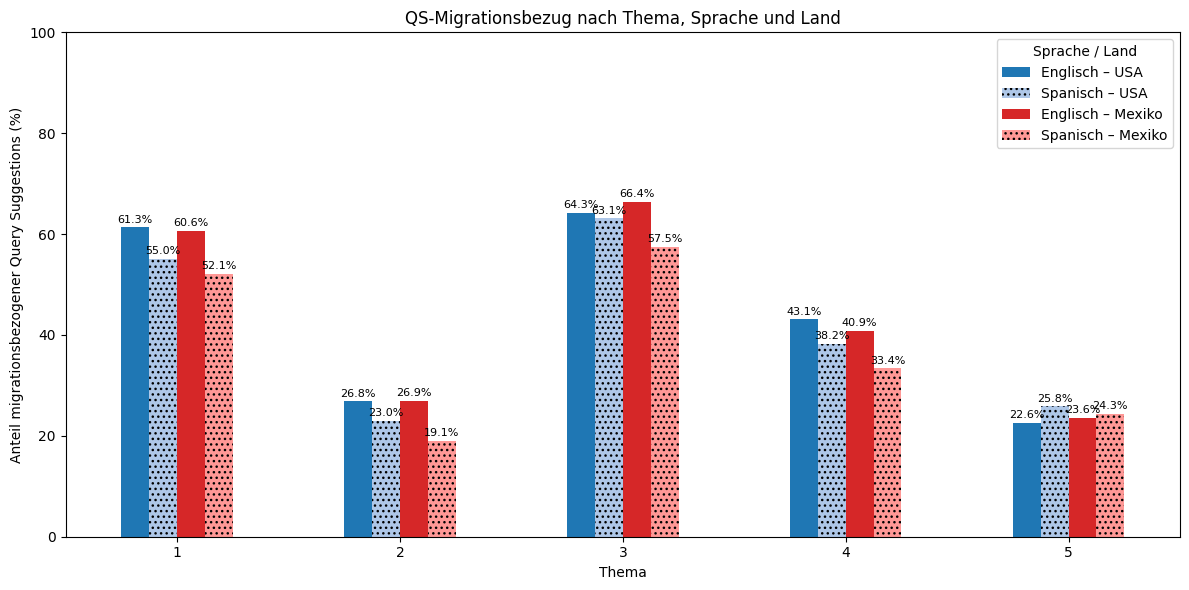

In [ ]:
import matplotlib.pyplot as plt

# Farben definieren
colors = [
    '#1f77b4',  # Englisch USA (dunkelblau)
    '#aec7e8',  # Spanisch USA (hellblau)
    '#d62728',  # Englisch Mexiko (dunkelrot)
    '#ff9896'   # Spanisch Mexiko (hellrot)
]

ax = plot_df.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

# ------------------------------------------------------------
# Hatches (Punkte für Spanisch)
# ------------------------------------------------------------
hatches = ['', '...', '', '...']  # nur Spanisch bekommt Punkte

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

# ------------------------------------------------------------
# Labels & Layout
# ------------------------------------------------------------
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema, Sprache und Land')

plt.xticks(rotation=0)

ax.legend([
    'Englisch – USA',
    'Spanisch – USA',
    'Englisch – Mexiko',
    'Spanisch – Mexiko'
], title='Sprache / Land')

# Prozentwerte anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()